## Run PCA and project the other simulations into the space of the first 2 PCs

In [1]:
import mdtraj as md
import numpy as np

from tqdm import tqdm
from glob import glob

from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Circle

from scipy import spatial

In [2]:
# first, we need the crystal data

CRYSTAL_ATOM_SELECTION = '(element != H) and is_protein and (resi < 303) and (resi > 0)'

def load_simulation(glob_pattern, top_path, subsampling=1, atom_selection=CRYSTAL_ATOM_SELECTION, Ca_only=True, center=True):

    md_files = sorted(glob(glob_pattern))
    print(f"found {len(md_files)} trajectory files...")
    
    md_sim = None

    for f in tqdm(md_files):
    
        t = md.load(f, top=top_path)[::subsampling]
    
        idx = t.top.select(atom_selection)
        t   = t.atom_slice(idx)

        if Ca_only:
            idx = t.top.select('name == CA')
            t   = t.atom_slice(idx)
    
        if md_sim == None:
            md_sim = t
        else:
            md_sim += t

    if center:
        md_sim = md_sim.center_coordinates()
    
    return md_sim
    

def load_pdbs(glob_pattern, Ca_only=True):
    
    crystals = None
    files_to_load = sorted(glob(glob_pattern))
    
    for pdb in tqdm(files_to_load):

        try:
            
            trj = md.load_pdb(pdb)
            idx = trj.top.select(CRYSTAL_ATOM_SELECTION)
            trj = trj.atom_slice(idx)

            if Ca_only:
                idx = trj.top.select('name == CA')
                trj = trj.atom_slice(idx)

            if crystals:
                crystals = crystals.join(trj, check_topology=False)
            else:
                crystals = trj

        except Exception as exptn:
            print(trj.xyz.shape)
            print(crystals.xyz.shape)
            print("something went wrong", pdb, exptn)

    crystals = crystals.center_coordinates()
    
    return crystals


def featurize_all_dihedrals(traj):
    
    features = []
    for fxn in [md.compute_phi,
                md.compute_psi]:
        _, angles = fxn(traj)
        
        features.append( np.sin(angles) )
        features.append( np.cos(angles) )
    
    return np.hstack(features)

In [3]:
crystals = load_pdbs('../../allostery/selected_dataset_archive_2024-08-07/pdb/*.pdb', Ca_only=False)

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/'
diamond = load_pdbs(prefix + '*.pdb', Ca_only=False)

 58%|█████▊    | 61/105 [00:10<00:07,  6.23it/s]

(1, 2323, 3)
(59, 2334, 3)
something went wrong /asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/Mpro-x1187_0.pdb Number of atoms in self (2334) is not equal to number of atoms in other


100%|██████████| 105/105 [00:18<00:00,  5.62it/s]


In [4]:
# then we need to cut down the MD simulations so they match the residue indices of the crystals

# DESRES
prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
glob_pattern = prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'
top_path = prefix + '/system_nowat.pdb'

desres_sim_subset = load_simulation(glob_pattern, top_path, subsampling=1, atom_selection=CRYSTAL_ATOM_SELECTION, Ca_only=False)

# RIKEN
# sampling is 200 ps, so subsampled 1/5 is 1 ns

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/RIKEN_mpro_simulation'
glob_pattern = prefix + '/Traj?/protein_snap_every200ps_*.xtc'
top_path = prefix + '/Traj1/protein_conf.gro'

riken_sim_subset = load_simulation(glob_pattern, top_path, subsampling=5, atom_selection=CRYSTAL_ATOM_SELECTION, Ca_only=False)

# Amaro Lab
# sampling is 100 ps, so subsampled 1/10 is 1 ns
# the simulation is split into two: different DCD and topologies for each chain...

prefix = '/gpfs/cfel/user/tjlane/mpro/mpro-simulations/TRAJECTORIES_INPUTS_DATA_mpro_wt_variants_amarolab/wt'

glob_pattern_chainA = prefix + '/wt_mpro_chainA_*.dcd'
top_path_chainA = prefix + '/wt_mpro_chainA_rep123.pr5.aligned_CA.not_waters_or_ions.psf'

amaro_sim_subset = load_simulation(glob_pattern_chainA, top_path_chainA, subsampling=10, atom_selection=CRYSTAL_ATOM_SELECTION, Ca_only=False)
amaro_sim_subset = amaro_sim_subset.superpose(amaro_sim_subset[0])

  0%|          | 0/100 [00:00<?, ?it/s]

found 100 trajectory files...


  0%|          | 0/6 [00:00<?, ?it/s]

found 6 trajectory files...


  0%|          | 0/3 [00:00<?, ?it/s]

found 3 trajectory files...


100%|██████████| 3/3 [00:20<00:00,  6.92s/it]


In [5]:
crystal_features = featurize_all_dihedrals(crystals)
diamond_features = featurize_all_dihedrals(diamond)
desres_features = featurize_all_dihedrals(desres_sim_subset)
riken_features = featurize_all_dihedrals(riken_sim_subset)
amaro_features = featurize_all_dihedrals(amaro_sim_subset)

all_features = [crystal_features, diamond_features, desres_features, riken_features, amaro_features]

for features in all_features:
    print(features.shape)

(1146, 1204)
(104, 1204)
(100000, 1204)
(20000, 1204)
(33000, 1204)


In [17]:
# titles = ["lig. free M$^\mathrm{pro}$ crystals", "Diamond", "DESRES MD Sim.", "RIKEN MD Sim.", "Amaro MD Sim."]
titles = ["DESY", "Diamond", "DESRES", "RIKEN", "Amaro"]

working on DESY
working on diamond
working on DESRES
working on RIKEN
working on Amaro


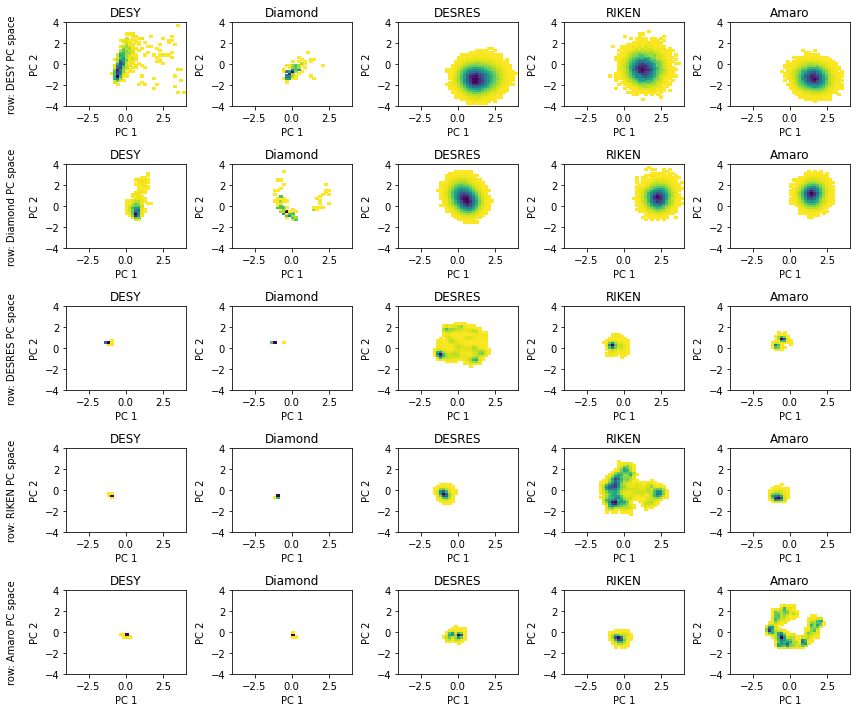

In [18]:
plt.figure(figsize=(12,10))

for ib in range(len(all_features)):

    print("working on", filenames[ib])
    
    pca = PCA(n_components=2, svd_solver='full', whiten=True)
    Y_tr = pca.fit_transform(all_features[ib])
    
    for i_f, features in enumerate(all_features):
    
        Y = pca.transform(features)
    
        ax = plt.subplot(len(all_features), len(all_features), ib*len(all_features) + i_f + 1)
        ax.hist2d(Y[:,0], Y[:,1], bins=40, cmap='viridis_r', density=True, cmin=.001, range=[(-4, 4), (-4, 4)])
    
        #circle = Circle((-1.2, 0.5), 0.3, color='blue', fill=False, linewidth=2)
        #ax.add_patch(circle)
    
        ax.set_xlabel("PC 1")

        if i_f == 0:
            ax.set_ylabel(f"row: {titles[ib]} PC space\n\nPC 2")
        else:
            ax.set_ylabel("PC 2")
    
        ax.set_title(titles[i_f])
    
plt.tight_layout()
plt.savefig(f"./figures/PCs_comparison.pdf")
plt.show()